
# Tutorial 5 - Transformers as Cognitive Models in Neuroscience and Psychology

This notebook presents transformer language models as explicit computational
models of human language processing. We compare model-internal signals
(surprisal, embeddings, attention) with behavioral and theoretical constructs
from cognitive neuroscience and psycholinguistics. **Enter your answers in [this form](https://forms.gle/5xK8goMNsrx12tjQA).**

## Conceptual Background

Transformer language models are trained to predict the next word.
Despite this simple objective, they develop internal representations
that capture syntax, semantics, and discourse structure.

In cognitive neuroscience, language processing is often studied using:

- Reading times
- Predictability (surprisal)
- Representational similarity
- Syntactic ambiguity effects

Here we treat transformers as *mechanistic hypotheses* about these processes.


## 0. Installs, imports, auxiliary functions

Let's start by installing relevant packages (`transformers`, `transformer_lens` and `circuitsvis`) and importing all the ones we need (these ones plus the usual suspects).

In [1]:
#@title Run this code, but feel free to ignore it. {display-mode: "form" }
!pip -q install transformers
!pip install transformer_lens circuitsvis

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, BertTokenizer, BertModel
from sklearn.linear_model import LinearRegression
import pandas as pd
import tqdm
import matplotlib.colors as mcolors
import math
from sklearn.metrics.pairwise import cosine_similarity
from transformer_lens import HookedTransformer
import circuitsvis as cv

Now we define some functions we will need further on.

In [2]:
#@title Run this code, but feel free to ignore it. {display-mode: "form" }
def clean_token(tok):
    return [tt.replace("Ġ", "") for tt in tok]

def compute_word_surprisal(sentence_words, model, tokenizer, MAX_LEN=1024):

    sentence = " ".join(sentence_words)

    encoding = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=MAX_LEN
    )

    input_ids = encoding["input_ids"]
    offsets = encoding["offset_mapping"][0]

    seq_len = input_ids.shape[1]

    with torch.no_grad():
        outputs = model(input_ids)

    logits = outputs.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)

    token_surprisals = -log_probs.gather(
        2, shift_labels.unsqueeze(-1)
    ).squeeze(-1)

    token_surprisals = token_surprisals.squeeze(0).cpu().numpy()

    # Compute character boundaries of words
    word_boundaries = []
    current_pos = 0

    for word in sentence_words:
        start = sentence.find(word, current_pos)
        end = start + len(word)
        word_boundaries.append((start, end))
        current_pos = end + 1

    word_surprisals = []

    for start, end in word_boundaries:

        word_surp = 0.0
        found_token = False

        for token_idx, (tok_start, tok_end) in enumerate(offsets[1:]):  # skip first token
            if tok_start >= start and tok_end <= end:
                if token_idx < len(token_surprisals):
                    word_surp += token_surprisals[token_idx]
                    found_token = True

        if found_token:
            word_surprisals.append(word_surp)
        else:
            # Word falls beyond truncation limit
            word_surprisals.append(np.nan)

    return word_surprisals

def estimate_layer_means(model, tokenizer, texts, max_tokens=1200):
    """
    Estimate mean embedding vectors for all layers at once.

    Returns:
        layer_means: list of numpy arrays, one per layer
                     layer_means[layer] = mean vector of that layer
    """
    model.eval()
    device = next(model.parameters()).device

    # Initialize storage for each layer
    n_layers = model.config.n_layer + 1  # includes embedding layer
    collected = [[] for _ in range(n_layers)]
    total_tokens = 0

    for text in texts:
        encoding = tokenizer(text, return_tensors="pt")
        input_ids = encoding["input_ids"].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, output_hidden_states=True)

        hidden_states = outputs.hidden_states  # tuple: one per layer

        for layer_idx, hidden in enumerate(hidden_states):
            hidden_cpu = hidden[0].cpu().numpy()  # [seq_len, hidden_dim]
            for vec in hidden_cpu:
                collected[layer_idx].append(vec)
                total_tokens += 1
                if total_tokens >= max_tokens:
                    break
            if total_tokens >= max_tokens:
                break

        if total_tokens >= max_tokens:
            break

    # Compute mean vector per layer
    layer_means = []
    for layer_vecs in collected:
        mean_vec = np.mean(layer_vecs, axis=0)
        layer_means.append(mean_vec)

    return layer_means

def cosine_centered(a, b, mean_vec):
    """
    Compute cosine similarity between two vectors after subtracting mean_vec.
    """
    a_centered = a - mean_vec
    b_centered = b - mean_vec
    return np.dot(a_centered, b_centered) / (np.linalg.norm(a_centered) * np.linalg.norm(b_centered))

## 1. Loading GPT-2 and Inspecting its Architecture

We use GPT-2, a causal (left-to-right) transformer.
Causal models are suitable for modeling incremental human processing.

We explicitly request:
- Hidden states (layer-wise embeddings)
- Attention weights

In [21]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager"   #  crucial
)

model.config.use_cache = False
model.config.output_attentions = True

model.eval()
print("Model loaded.")
print("Number of layers:", model.config.n_layer)
print("Number of attention heads:", model.config.n_head)
print("Hidden size:", model.config.n_embd)

Model loaded.
Number of layers: 12
Number of attention heads: 12
Hidden size: 768


GPT-2 consists of:

1. Token and positional embeddings
2. A stack of transformer blocks
   - Multi-head self-attention
   - Feedforward (MLP) layer
   - Residual connections

# 2. Surprisal and Human Reading Time

Surprisal is defined as:

    surprisal(word) = -log P(word | context)

Higher surprisal corresponds to lower predictability. Traditionnally surprisal has been assessed using **n-grams**, here we will test whether surprisal can be (better) captured using the probabilities defined by GPT2.

Psycholinguistic research shows:
- Higher surprisal → longer reading time
- Higher surprisal → larger N400 responses

## 2.1 Reading time from natural stories corpus

We will compute token-level surprisal from GPT-2 on a given corpus and compare it to the average time to read each word (in the same context) in human participants. We will use the **real Natural Stories corpus ([Futrell et al., 2021](https://link.springer.com/article/10.1007/s10579-020-09503-7))**.
Let's download the CSV file containing word-level reading times from this Githup [repo](https://github.com/languageMIT/naturalstories).

Each row in the dataframe corresponds to one word in the corpus read by one participant. The relevant variables are `WorkerId` (participant id), the position of the word in the corpus (`item`), the word `word`, and the time they took to read it (`RT`).

In [4]:
url = "https://raw.githubusercontent.com/languageMIT/naturalstories/master/naturalstories_RTS/processed_RTs.tsv"

df = pd.read_csv(url, sep="\t")

df.head()

,WorkerId,WorkTimeInSeconds,correct,item,zone,RT,word,nItem,meanItemRT,sdItemRT,gmeanItemRT,gsdItemRT
0,A3QJPB0NZU5PY1,3960,6,1,1,637,If,84,578.964286,276.061345,527.81264,1.524238
1,A2RPQGUWVZPX7U,2431,5,1,1,1222,If,84,578.964286,276.061345,527.81264,1.524238
2,A11KMPAZSE5Q0Q,1287,5,1,1,416,If,84,578.964286,276.061345,527.81264,1.524238
3,A1U1QL617G5DU3,2074,6,1,1,571,If,84,578.964286,276.061345,527.81264,1.524238
4,ACTW5YEWV9OR0,2213,6,1,1,1208,If,84,578.964286,276.061345,527.81264,1.524238


Let's compute the **average reading time** (in ms) for each word across participants.



In [5]:
df_grouped = (
    df
    .groupby(["item", "zone", "word"])
    .agg(mean_RT=("RT", "mean"))
    .reset_index()
)

df_grouped.head()


,item,zone,word,mean_RT
0,1,1,If,578.964286
1,1,2,you,369.011905
2,1,3,were,368.183908
3,1,4,to,344.318182
4,1,5,journey,354.639535



## 2.2  Compute Word-by-Word Surprisal from Transformer
We now want to compute the surprisal corresponding to each word in the same context from GPT2. Let's first extract one sentence from the corpus to compare the GPT2 surprisal with reaction times on this example sentence.


In [6]:
# ---- Select example item ----
example_item = df_grouped["item"].unique()[0]
subset = df_grouped[df_grouped["item"] == example_item].reset_index(drop=True)
words = subset["word"].tolist()
mean_rts = subset["mean_RT"].tolist()

sentence = " ".join(words) # join words into sentence
sentence = sentence.split(".", 1)[0] + "." #take first sentence as example sentence
print("Example sentence:\n")
print(sentence)

Example sentence:

If you were to journey to the North of England, you would come to a valley that is surrounded by moors as high as mountains.


Here at each position in the sentence, we **extract the 5 most likely words to appear next** according to GPT2 and compare it with the probability for the actual word in the sentence. This is done by first passign all words until that position as input to the model, and computing from the model output (`out.logits`) the probability for the actual next word, as well as the 5 words with highest probabilities overall from the entire lexicon. On the plot below this is compared for each word with reaction time from the dataset.
**After observing the results, change the sentence by uncommenting the line below and type few example sentences of your choice. Observe the predicted words from GPT2 to evaluate how well the model captures grammar rules and semantic context.**

In [7]:
# sentence = "Type your sentence here."

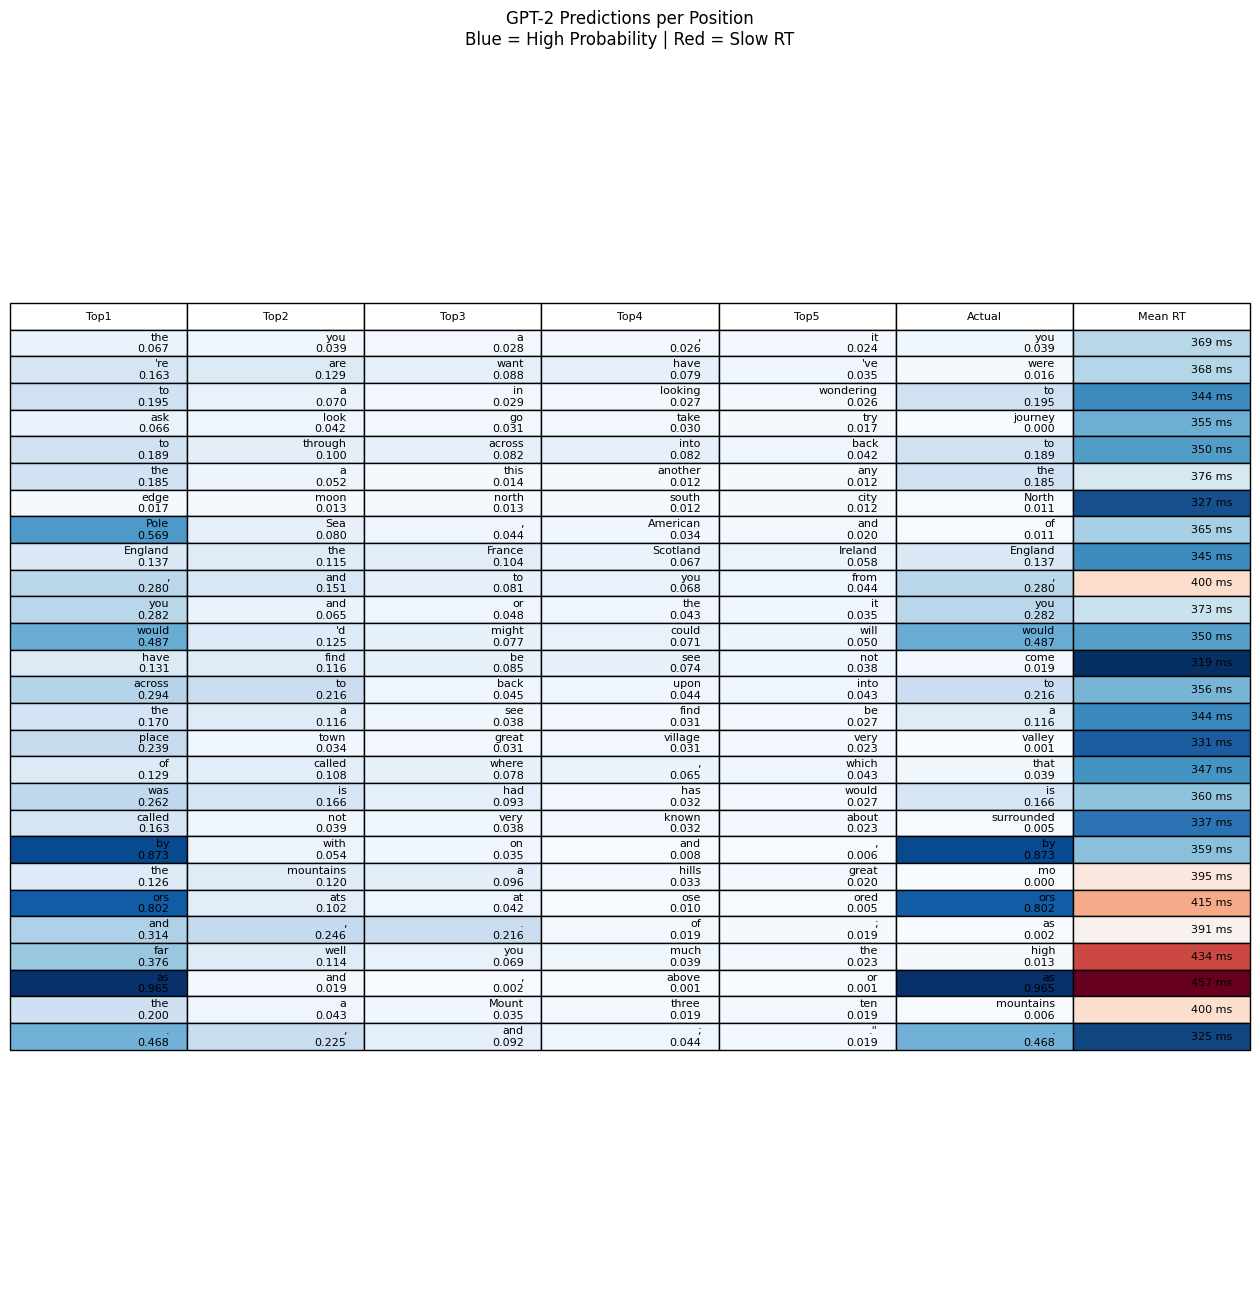

In [8]:
#embed words in high dimensional space (input to transformer)
inputs = tokenizer(sentence, return_tensors="pt")
input_ids = inputs["input_ids"]

results = []
prob_matrix = []
actual_probs = []

with torch.no_grad():
    outputs = model(**inputs)

for i in range(input_ids.shape[1] - 1): # for all positions in sentence

    # all words until the one we test
    context_ids = input_ids[:, :i+1]

    # pass it through transformer
    with torch.no_grad():
        out = model(input_ids=context_ids)

    # compute the logits at next position for all words in lexicon
    next_token_logits = out.logits[:, -1, :]

    # convert to probability using softmax
    probs = torch.nn.functional.softmax(next_token_logits, dim=-1)

    # extract the 5 words with max probability
    topk_probs, topk_ids = torch.topk(probs, 5)
    topk_probs = topk_probs[0].cpu().numpy()
    topk_words = clean_token(tokenizer.convert_ids_to_tokens(topk_ids[0]))

    # compute probability for actual next word
    actual_next_id = input_ids[0, i+1]
    actual_prob = probs[0, actual_next_id].item()
    actual_word = clean_token(tokenizer.convert_ids_to_tokens([actual_next_id]))[0]

    row_text = []
    row_probs = []

    for w, p in zip(topk_words, topk_probs):
        row_text.append(f"{w}\n{p:.3f}")
        row_probs.append(p)

    row_text.append(f"{actual_word}\n{actual_prob:.3f}")
    row_probs.append(actual_prob)

    results.append(row_text)
    prob_matrix.append(row_probs)
    actual_probs.append(actual_prob)

# ---- Add mean RT column ----
rt_values = mean_rts[1:1+len(results)]  # drop first word (no prediction)
rt_values = np.array(rt_values)

# Normalize probabilities and RTs for coloring
prob_matrix = np.array(prob_matrix)
all_probs = prob_matrix.flatten()
prob_norm = mcolors.Normalize(vmin=all_probs.min(), vmax=all_probs.max())

rt_norm = mcolors.Normalize(vmin=rt_values.min(), vmax=rt_values.max())

# ---- Build color matrix ----
cell_colors = []

for row_idx, row in enumerate(prob_matrix):
    row_colors = []
    for p in row:
        color = plt.cm.Blues(prob_norm(p))
        row_colors.append(color)

    # RT column (red for slow, blue for fast)
    rt_color = plt.cm.RdBu_r(rt_norm(rt_values[row_idx]))
    row_colors.append(rt_color)

    cell_colors.append(row_colors)

# Add RT column text
for i in range(len(results)):
    results[i].append(f"{rt_values[i]:.0f} ms")

column_labels = ["Top1", "Top2", "Top3", "Top4", "Top5", "Actual", "Mean RT"]

fig, ax = plt.subplots(figsize=(16, len(results)*0.6))
ax.axis('off')

table = ax.table(
    cellText=results,
    colLabels=column_labels,
    cellColours=cell_colors,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.6)

plt.title("GPT-2 Predictions per Position\nBlue = High Probability | Red = Slow RT")
plt.show()

**Q1 - Based on testing various example sentences, does GPT2 make correct grammatical predictions?**

*copy your response in form.*

**Q2- what about semantic predictions?**

*copy your response in form.*

Now we will do compute the surprisal (i.e. the negative logarithm of the probability of the observed word given previous words, according to GPT2) from each word in the corpus. Because GPT2 can only process sequences of 1024 words, we will actually trim the stories and only process those first 1024 words (values afterwards are assigned with nan). This number marks somewhat the memory span of the model (it increased in more recent models).
This will take few minutes.

In [9]:
MAX_LEN = 1024  # GPT-2 positional limit

all_words = []
all_surprisals = []
all_meanRT = []

#for item_id in tqdm(df_grouped["item"].unique()):
for item_id in df_grouped["item"].unique():

    subset = df_grouped[df_grouped["item"] == item_id].reset_index(drop=True)

    words = subset["word"].tolist()
    mean_rts = subset["mean_RT"].tolist()

    word_surps = compute_word_surprisal(words, model, tokenizer, MAX_LEN=MAX_LEN)

    assert len(word_surps) == len(mean_rts)

    all_surprisals.extend(word_surps)
    all_meanRT.extend(mean_rts)

print("Total aligned words:", len(all_words))


Total aligned words: 0



### comparing GPT surprisal against human reading time

Let's finally test whether the surprisal given by the model captures some of the variability of human reading time across words by correlating the two variables.


In [10]:
from scipy.stats import pearsonr

df_corr = pd.DataFrame({
    "surprisal": all_surprisals,
    "RT": all_meanRT
}).dropna()

r, p = pearsonr(df_corr["surprisal"], df_corr["RT"])
r2 = r**2

print(f"r = {r:.3f}")
print(f"r² = {r2:.3f}")
print(f"p = {p:.5f}")



r = 0.297
r² = 0.088
p = 0.00000


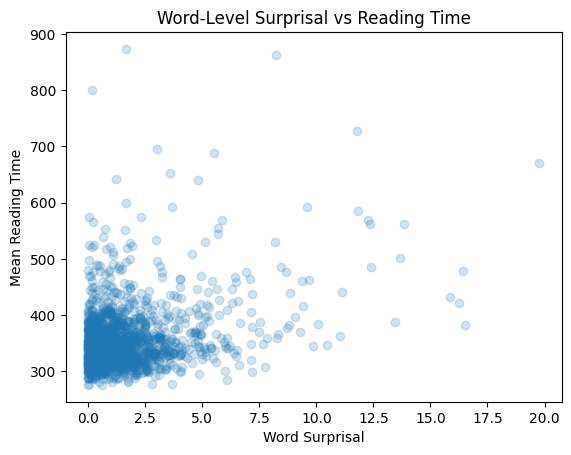

In [11]:
plt.figure()
plt.scatter(all_surprisals, all_meanRT, alpha=0.2)
plt.xlabel("Word Surprisal")
plt.ylabel("Mean Reading Time")
plt.title("Word-Level Surprisal vs Reading Time")
plt.show()


**Q3 - What do you observe?**

*copy your response in form.*

**Q4 - what other variables could explain reading time?**

*copy your response in form.*

# 3. Word embeddings
To understand better the concept of embeddings, let us study how the embeddings for a given word ("bank") varies across layers of the transformer depending on its context. We will use three different meanings for the word "bank": financial institution (noun), river bank (noun), to rely one or store (verb), with 5 sentences for each meaning.

In [12]:
sentences = [
    # Institution (financial)
    "The bank approved the loan for the new house.",
    "She works at the bank as a financial advisor.",
    "The bank raised interest rates to combat inflation.",
    "He opened a savings account at the local bank.",
    "The central bank announced new economic policies.",

    # River bank (land alongside a river)
    "He sat on the river bank, watching the sunset.",
    "The canoe hit the muddy bank during the storm.",
    "They picnicked on the bank of the river last weekend.",
    "The children found shells along the bank of the lake.",
    "The fisherman cast his line from the grassy bank.",

    # Verb (to rely on or store for future use)
    "She decided to bank on her experience for the job interview.",
    "He will bank the fire to keep it burning slowly overnight.",
    "He plans to bank his savings for a rainy day.",
    "The pilot will bank the plane sharply to avoid turbulence.",
    "The team will bank their hopes on the star player."
]

Let's extract the embedding for the word "bank" in all these sentences. Remember, at each layer there is one embedding (i.e. representation of the word in a large dimension space) for each word in the processed sequence. Embeddings can be read from the output of the model using `outputs.hidden_states[layer]`.
Importantly, the inputs that are embedded are *tokens* where one token can be one full word, or sometimes a part of a word (e.g. a suffix). So here what we will do when a word is decomposed into multiple tokens is to average the embeddings for these different tokens.

In [13]:
model.eval()

def get_word_embedding(sentence, target_word, layer):
    encoding = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True
    )

    # encoding of sentence
    input_ids = encoding["input_ids"]
    offsets = encoding["offset_mapping"][0]

    # pass it through model
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            output_hidden_states=True
        )

    #extract embeddings at given layer
    hidden = outputs.hidden_states[layer][0]

    # Find target word span in sentence
    start_char = sentence.lower().find(target_word.lower())
    end_char = start_char + len(target_word)

    token_embeddings = []

    for i, (tok_start, tok_end) in enumerate(offsets):

        # skip special tokens
        if tok_start == tok_end:
            continue

        # check overlap
        if tok_start < end_char and tok_end > start_char:
            token_embeddings.append(hidden[i].numpy())

    if len(token_embeddings) == 0:
        raise ValueError(f"Could not find token for {target_word}")

    # average if multiple subwords
    return np.mean(token_embeddings, axis=0)

How similar is the representation of the word "bank" across different contexts? We quantify this using the *cosine similarity* as a measure of distance between embeddings. The cosine similarity is the cosine of the angle formed by a pair of vectors (in high dimension) corresponding to each word. The larger it is, the closer. The matrices below represent the similarity between embeddings of the word "bank" in the 15 different sentences, evaluated separately at different layers.

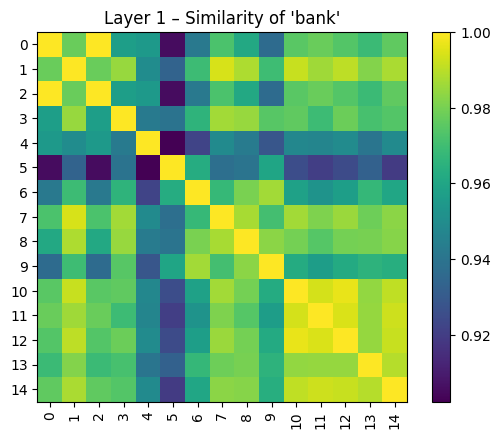

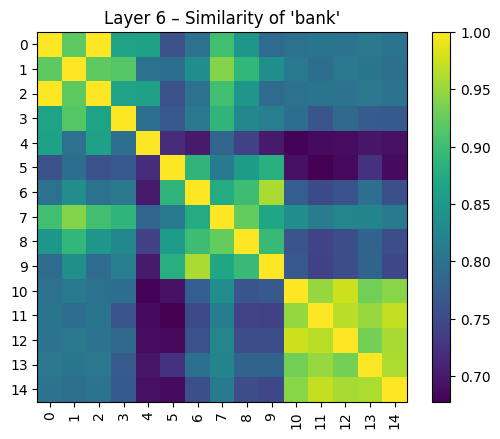

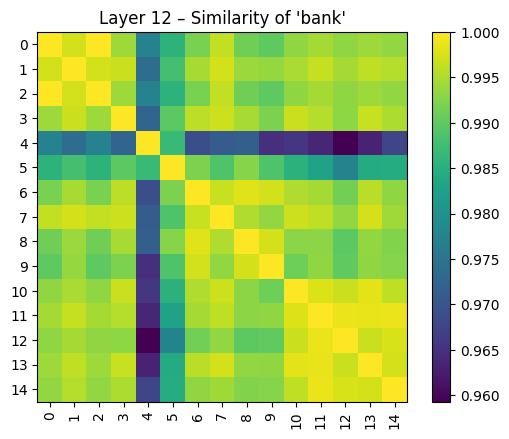

In [32]:
layers_to_plot = [1, 6, 12]  # early, middle, final

for layer in layers_to_plot:

    embeddings = []

    for sent in sentences:
        emb = get_word_embedding(sent, "bank", layer)
        embeddings.append(emb)

    sim_matrix = cosine_similarity(embeddings)

    plt.figure()
    plt.imshow(sim_matrix)
    plt.xticks(range(len(sentences)), range(len(sentences)), rotation=90)
    plt.yticks(range(len(sentences)), range(len(sentences)))
    plt.title(f"Layer {layer} – Similarity of 'bank'")
    plt.colorbar()
    plt.show()


**Q5- What do you observe?**

*copy your response in form.*

**Q6 - What mechanism is responsible for the changes in embeddings depending on context?**

*copy your response in form.*

# 4. Attention heads and the encoding of linguistic rules

The encoding of words changes through the layers of the transformer based on context through the attention mechanism. We will explore this, in more detail.
We will look in particular at **attention heads** which allow to measure the influence of one word onto another. Multi-heads attention means that there are multiple attention heads at each layer, multiplexing the reciprocal influences (grammatical, lexical, semantic, etc.) of words within the sequence.
In general, it is very hard to pinpoint the exact role of each attention head in the network. Their role is rather diffuse, perhaps similar to mixed selectivity in primate cortex.
We focus here on a few counter-examples of specific heads in various models where the precise role has been clearly identified (although it's never as clear cut as an abstract rule).
Let's start with attention head L1H5 (layer 1, head 5) from GPT2-Small.
We will process a sequence made of 25 words.
Caution! Here we're using the 0-index number for layers and heads - it's actually the sixth head from second layer (layer 0, layer 1, etc.)

From here we will use `HookedTransformer`, a dedicated library to dissect transformers. We will plot the **token-to-token attention matrix** for this head, which represents the reciprocal influence of the word embeddings (which word attend to which) through this particular head.

In [16]:
# 1. Load GPT2-Small
model = HookedTransformer.from_pretrained("gpt2-small")

# 2. Define 5 categories with 5 examples each
# Organized to create contiguous blocks in the attention matrix
categories = {
    "Days": [" Monday", " Tuesday", " Wednesday", " Thursday", " Friday"],
    "Colors": [" red", " blue", " green", " yellow", " purple"],
    "Animals": [" cat", " dog", " horse", " bird", " fish"],
    "Countries": [" Spain", " Germany", " Ghana", " Brazil", " Indonesia"],
    "Years": [" 1900", " 1920", " 1960", " 2000", " 2010"]
}

# Flatten the categories into a single prompt string
prompt_list = []
for cat in categories.values():
    prompt_list.extend(cat)

prompt = "".join(prompt_list)
tokens = model.to_tokens(prompt)
str_tokens = model.to_str_tokens(tokens)

# 3. Run model and get Layer 1 Head 5
logits, cache = model.run_with_cache(tokens)
# Shape: [Batch, Head, Query, Key] -> Extract Batch 0, Head 5
attn_pattern = cache["pattern", 1][0, 5]

# 4. Render
print(f"Visualizing L1H5 Clustering (25 tokens)")
cv.attention.attention_heads(
    attention=attn_pattern.unsqueeze(0),
    tokens=str_tokens
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Visualizing L1H5 Clustering (25 tokens)


**Q7 - What words do each word attend to through this head? What could it be useful for?**

*copy your response in form.*

We will now switch to another popular open-source model: BERT. Let's download it.

In [17]:
# Load BERT-BASE / uncased
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertModel.from_pretrained(
    model_name,
    output_attentions=True   # enables attention outputs
)

model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [18]:
def bert_attention_for_sentence(sentence):
    """
    Tokenize and run BERT to get attentions.
    Returns tokens, attention tensors (layers x heads x seq x seq).
    """

    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs)

    # attentions is a tuple: one tensor per layer
    # each is (batch, heads, seq_len, seq_len)
    attentions = outputs.attentions

    # Squeeze batch dimension
    attentions = [a[0].cpu().numpy() for a in attentions]

    return tokens, attentions

def plot_attention_head(attn_matrix, tokens, layer_idx, head_idx):
    """
    Plot a single attention head's matrix with tokens labeled.
    """
    fig, ax = plt.subplots(figsize=(6,6))

    im = ax.imshow(attn_matrix, cmap='viridis')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"Layer {layer_idx} Head {head_idx}")

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.show()

Let's look at the behaviour of attention head 5 from layer 6 for this model. **Try it for the first sentence below, then for the second. Then try again with examples of your choice to try to isolate the attention mechanism in this head.**

['[CLS]', 'nobody', "'", 's', 'fault', 'but', 'mine', ',', 'and', 'my', 'soul', 'be', 'lost', '.', '[SEP]']


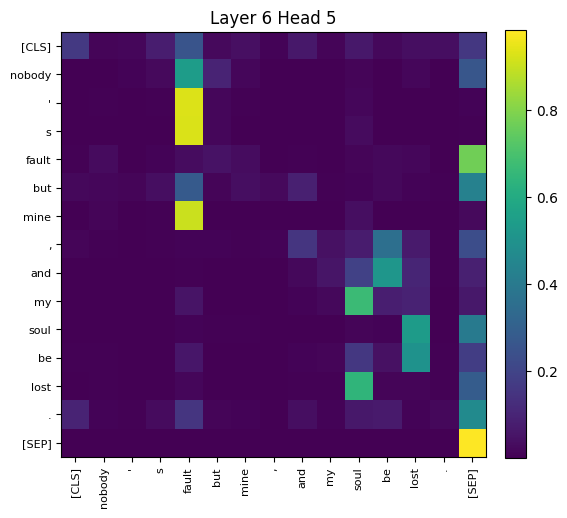

In [19]:
sentence1 = "The enemy of my enemy is my friend, not Michael's."
sentence1 = "Nobody's fault but mine, and my soul be lost."

layer = 6 # index of layer (starts at 0)
head = 5 # index of attention head (starts at 0)

tokens1, attentions1 = bert_attention_for_sentence(sentence1)

print(tokens1)
plot_attention_head(attentions1[layer][head], tokens1, layer, head)

**Q8 - What do you think is the role of this head?**

*copy your response in form.*

**Do the same with head 10 from layer 7**

['[CLS]', 'the', 'old', 'cat', 'learned', 'the', 'chinese', 'language', 'from', 'an', 'amusing', 'character', '.', '[SEP]']


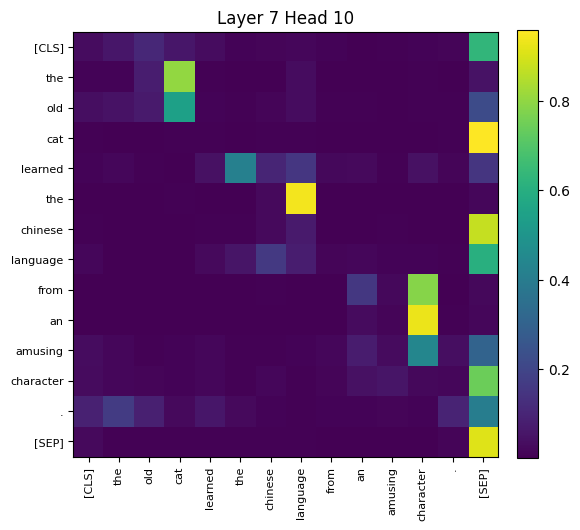

In [20]:
# noun pre-modifiers
sentence1 = "The complicated language in the huge new law has tempered the fight."
sentence1 = "The old cat learned the Chinese language from an amusing character."

tokens1, attentions1 = bert_attention_for_sentence(sentence1)

layer = 7 # index of layer (starts at 0)
head = 10 # index of attention head (starts at 0)

print(tokens1)
plot_attention_head(attentions1[layer][head], tokens1, layer, head)

**Q9 - What is the role of this head?**

*copy your response in form.*

Learn more about the role of attention heads in LLMs in [this PNAS paper](https://www.pnas.org/doi/10.1073/pnas.1907367117) (where the last two examples were taken from).